In [1]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.loader import load_specs
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir, BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicGRU_L1_Move, BasicGRU_L2_Dir, BasicLSTM_L3_Regression, BasicGRU_L3_Regression
from tradepy.supervised.train import train_walk_forward_2level, grid_search_thresholds, create_lstm_dataset
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_2level, load_trading_model_3level
from tradepy.supervised.backtest import prepare_bt, create_test_dataset, predict_in_batches, run_backtest_complete, run_backtest_complete_scalein, run_backtest_sizing_only, run_backtest_scalein_sizing, build_overlapping_blocks, monte_carlo_blocks
from tradepy.paths import MODELS_DIR, BT_DIR

import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt


In [2]:
symbols = load_symbols()
cfg = load_config()

In [3]:
symbols

['AD',
 'BP',
 'CL',
 'EC',
 'ES',
 'GC',
 'MFXI',
 'NG',
 'NQ',
 'YM',
 'ZB',
 'ZN',
 'ZS']

In [4]:
ASSET = symbols[11]
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880

In [5]:
(
    model_l1,
    model_l2,
    model_l3,
    sc_features,
    sc_l3,
    features,
    params,
    thresholds,
    df_results
) = load_trading_model_3level(
        BasicLSTM_L1_Move,
        BasicLSTM_L2_Dir,
        BasicLSTM_L3_Regression,
        path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_lstm_3level",
        device="cuda"
)


🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/zn/trading_model_lstm_3level
📌 Features: 65
📌 Thresholds cargados: True
📁 Resultados cargados: True


In [6]:
(
    model_l1_g,
    model_l2_g,
    model_l3_g,
    sc_features_g,
    sc_l3_g,
    features_g,
    params_g,
    thresholds_g,
    df_results_g
) = load_trading_model_3level(
        BasicGRU_L1_Move,
        BasicGRU_L2_Dir,
        BasicGRU_L3_Regression,
        path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_gru_3level",
        device="cuda"
)


🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/zn/trading_model_gru_3level
📌 Features: 65
📌 Thresholds cargados: True
📁 Resultados cargados: True


In [7]:
ASSET

'ZN'

In [8]:
df_bt, spec_bt = prepare_bt(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")

In [9]:
df_bt

,datetime,open,high,low,close,volume,openint,per,trading_date,open_day,...,nearest_fib_level,dist_to_nearest_fib,swing_extension,bars_between_swing_highs,bars_between_swing_lows,swing_high_velocity,swing_low_velocity,bars_between_swings,swing_cycle_ratio,ticker
0,2025-12-26 00:00:00+00:00,112.375000,112.375000,112.375000,112.375000,2.0,0.0,240min,2025-12-25,112.375000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZN
1,2025-12-26 04:00:00+00:00,112.375000,112.375000,112.312500,112.312500,5.0,0.0,240min,2025-12-26,112.375000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZN
2,2025-12-26 08:00:00+00:00,112.312500,112.312500,112.312500,112.312500,0.0,0.0,240min,2025-12-26,112.375000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZN
3,2025-12-26 12:00:00+00:00,112.312500,112.437500,112.281250,112.437500,3.0,0.0,240min,2025-12-26,112.375000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZN
4,2025-12-26 16:00:00+00:00,112.406250,112.546875,112.406250,112.546875,6.0,0.0,240min,2025-12-26,112.375000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
754,2026-06-18 08:00:00+00:00,109.828125,109.828125,109.828125,109.828125,0.0,0.0,240min,2026-06-18,109.828125,...,0.382,0.050432,-0.567568,4.0,7.0,0.144531,0.082589,0.0,1.0,ZN
755,2026-06-18 12:00:00+00:00,109.828125,109.828125,109.281250,109.703125,108.0,0.0,240min,2026-06-18,109.828125,...,0.236,-0.019784,-0.783784,4.0,7.0,0.144531,0.082589,0.0,1.0,ZN
756,2026-06-18 16:00:00+00:00,109.656250,110.093750,109.656250,109.968750,354.0,0.0,240min,2026-06-18,109.828125,...,0.618,0.057676,-0.324324,4.0,7.0,0.144531,0.082589,0.0,1.0,ZN
757,2026-06-18 20:00:00+00:00,109.968750,109.968750,109.968750,109.968750,0.0,0.0,240min,2026-06-18,109.828125,...,0.786,-0.000286,-0.214286,4.0,4.0,0.144531,0.218750,4.0,1.0,ZN


In [10]:
# start = "2026-03-27"
start = "2026-01-20"
end   = "2026-06-01"

mask = (df_bt["datetime"] >= start) & (df_bt["datetime"] < end)
df_filtered = df_bt.loc[mask]


In [11]:
df_bt["datetime"].dt.hour

0       0
1       4
2       8
3      12
4      16
       ..
754     8
755    12
756    16
757    20
758     0
Name: datetime, Length: 759, dtype: int32

<Axes: ylabel='Frequency'>

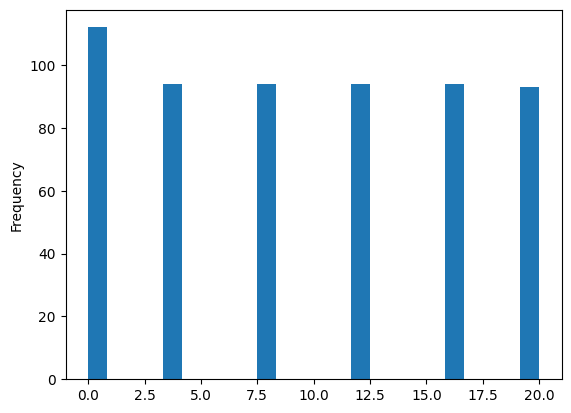

In [12]:
df_filtered["hour"] = df_filtered["datetime"].dt.hour
df_filtered["hour"].plot.hist(bins=24)


In [13]:
test, test_dt = create_test_dataset(df_filtered, features, lookback=30)

In [14]:
test_dt

0     2026-01-26 20:00:00+00:00
1     2026-01-27 00:00:00+00:00
2     2026-01-27 04:00:00+00:00
3     2026-01-27 08:00:00+00:00
4     2026-01-27 12:00:00+00:00
                 ...           
546   2026-05-29 08:00:00+00:00
547   2026-05-29 12:00:00+00:00
548   2026-05-29 16:00:00+00:00
549   2026-05-29 20:00:00+00:00
550   2026-05-30 00:00:00+00:00
Name: datetime, Length: 551, dtype: datetime64[us, UTC]

In [15]:
test_g, test_dt_g = create_test_dataset(df_filtered, features_g, lookback=30)

In [16]:
test

array([[[-1.00000000e+02,  0.00000000e+00,  3.12324164e+01, ...,
         -1.53975364e-03,  1.80327869e-01, -5.77464789e+01],
        [-9.51219512e+01,  0.00000000e+00,  3.18086026e+01, ...,
         -1.39958013e-03,  1.38643068e-01, -5.07246377e+01],
        [-9.31818182e+01,  0.00000000e+00,  3.26639415e+01, ...,
         -9.80529486e-04,  2.90964778e-02, -5.71428571e+01],
        ...,
        [-3.70370370e+00,  0.00000000e+00,  2.33151694e+01, ...,
          1.68161435e-03, -1.38888889e-02,  2.36363636e+01],
        [-0.00000000e+00,  0.00000000e+00,  2.23779532e+01, ...,
          2.24215247e-03,  2.94612795e-03,  3.10344828e+01],
        [-1.33333333e+01,  1.00000000e+00,  2.11293113e+01, ...,
          1.26068077e-03, -3.77754460e-03,  1.57894737e+01]],

       [[-9.51219512e+01,  0.00000000e+00,  3.18086026e+01, ...,
         -1.39958013e-03,  1.38643068e-01, -5.07246377e+01],
        [-9.31818182e+01,  0.00000000e+00,  3.26639415e+01, ...,
         -9.80529486e-04,  2.90964778e

In [17]:
test_flat = test.reshape(-1, test.shape[-1])


In [18]:
test_flat

array([[-1.00000000e+02,  0.00000000e+00,  3.12324164e+01, ...,
        -1.53975364e-03,  1.80327869e-01, -5.77464789e+01],
       [-9.51219512e+01,  0.00000000e+00,  3.18086026e+01, ...,
        -1.39958013e-03,  1.38643068e-01, -5.07246377e+01],
       [-9.31818182e+01,  0.00000000e+00,  3.26639415e+01, ...,
        -9.80529486e-04,  2.90964778e-02, -5.71428571e+01],
       ...,
       [-1.36363636e+01,  0.00000000e+00,  2.69859518e+01, ...,
         1.56294402e-03, -1.33097802e-02,  1.11111111e+01],
       [-9.09090909e+00,  1.00000000e+00,  2.75431669e+01, ...,
         1.13587960e-03, -4.71133512e-03,  1.42857143e+01],
       [-1.59090909e+01,  1.00000000e+00,  2.80605810e+01, ...,
         5.67859171e-04, -9.31018486e-04,  1.55555556e+01]],
      shape=(16530, 65))

In [19]:
test_scaled =sc_features.transform(test_flat).reshape(test.shape)

In [20]:
logits_l1 = predict_in_batches(model_l1, test_scaled)
probs_l1 = torch.softmax(logits_l1, dim=1).numpy()


In [21]:
df_probs = pd.DataFrame(
    probs_l1,
    columns=["prob_hold", "prob_move"]
)

In [22]:
logits_l2 = predict_in_batches(model_l2, test_scaled)
probs_l2 = torch.softmax(logits_l2, dim=1).numpy()


In [23]:
df_probs_l2 = pd.DataFrame(
    probs_l2,
    columns=["prob_short", "prob_long"]
)

In [24]:
df_probs[["prob_short", "prob_long"]] = df_probs_l2


In [25]:
thresholds

{'threshold_move': 0.65, 'threshold_dir': 0.5}

In [26]:
logits_l3 = predict_in_batches(model_l3, test_scaled)
preds_l3 = logits_l3.numpy().reshape(-1)


In [27]:
df_probs["pred_l3"] = preds_l3

In [28]:
df_probs["pred_l1"] = (df_probs['prob_move'] > thresholds["threshold_move"]).astype(int)

In [29]:
df_probs["pred_l2"] =  (df_probs['prob_long'] > thresholds["threshold_dir"]).astype(int)

In [30]:
df_probs["datetime"] = test_dt.values

In [31]:
df_probs["pred"] = np.where(
    df_probs["pred_l1"] == 0,
    1,
    np.where(df_probs["pred_l2"] == 0, 0, 2)
)


In [32]:
df_final_triple_real = target_triple_barrier_interday(df_filtered, spec_bt, return_horizon_days=int(RETURN_HORIZON_MIN/60/24), profit_factor=1.8, tp_atr_mult=1.4, sl_atr_mult=1.2)
df_final_triple_real["target_class"] = df_final_triple_real[f"target_tb_{int(RETURN_HORIZON_MIN/60/24)}d"]
df_final_triple_real["target_regression"] = df_final_triple_real[f"log_return_horizon_{RETURN_HORIZON_MIN}m"]

In [33]:
df_final_triple_real

,datetime,open,high,low,close,volume,openint,per,trading_date,open_day,...,bars_between_swing_lows,swing_high_velocity,swing_low_velocity,bars_between_swings,swing_cycle_ratio,ticker,target_tb_2d,logreturn_tb_2d,target_class,target_regression
97,2026-01-20 00:00:00+00:00,111.453125,111.500000,111.453125,111.453125,21.0,0.0,240min,2026-01-19,111.796875,...,5.0,0.018750,0.137500,3.0,1.00,ZN,1.0,NaN,1.0,-0.005453
98,2026-01-20 04:00:00+00:00,111.453125,111.546875,111.453125,111.484375,196.0,0.0,240min,2026-01-20,111.453125,...,7.0,0.018750,0.049107,4.0,1.00,ZN,0.0,-0.000687,0.0,-0.005172
99,2026-01-20 08:00:00+00:00,111.468750,111.500000,111.390625,111.437500,100.0,0.0,240min,2026-01-20,111.453125,...,7.0,0.018750,0.049107,4.0,1.25,ZN,0.0,-0.000623,0.0,-0.004895
100,2026-01-20 12:00:00+00:00,111.390625,111.406250,111.281250,111.312500,136.0,0.0,240min,2026-01-20,111.453125,...,7.0,0.015625,0.049107,2.0,0.00,ZN,0.0,-0.000662,0.0,-0.003363
101,2026-01-20 16:00:00+00:00,111.312500,111.468750,111.203125,111.421875,469.0,0.0,240min,2026-01-20,111.453125,...,7.0,0.015625,0.049107,2.0,0.50,ZN,0.0,-0.000773,0.0,-0.001681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,2026-05-29 00:00:00+00:00,110.046875,110.109375,110.015625,110.062500,3762.0,0.0,240min,2026-05-28,109.750000,...,1.0,0.114583,0.609375,2.0,0.00,ZN,1.0,NaN,1.0,0.001421
672,2026-05-29 04:00:00+00:00,110.062500,110.187500,110.062500,110.156250,1038.0,0.0,240min,2026-05-29,110.062500,...,1.0,0.114583,0.609375,2.0,0.50,ZN,1.0,NaN,1.0,0.001562
673,2026-05-29 08:00:00+00:00,110.156250,110.156250,110.000000,110.015625,258.0,0.0,240min,2026-05-29,110.062500,...,1.0,0.114583,0.609375,2.0,1.00,ZN,1.0,NaN,1.0,0.000426
674,2026-05-29 12:00:00+00:00,110.031250,110.156250,109.968750,110.140625,3242.0,0.0,240min,2026-05-29,110.062500,...,1.0,0.213542,0.609375,5.0,0.00,ZN,1.0,NaN,1.0,0.002130


In [34]:
df_final_triple_real["target_class"]

97     1.0
98     0.0
99     0.0
100    0.0
101    0.0
      ... 
671    1.0
672    1.0
673    1.0
674    1.0
675    1.0
Name: target_class, Length: 576, dtype: float64

In [35]:
df_probs

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-26 20:00:00,1
1,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 00:00:00,1
2,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 04:00:00,1
3,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 08:00:00,1
4,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 12:00:00,1
...,...,...,...,...,...,...,...,...,...
546,0.308868,0.691132,0.323362,0.676638,0.148771,1,1,2026-05-29 08:00:00,2
547,0.278631,0.721369,0.357152,0.642848,0.141385,1,1,2026-05-29 12:00:00,2
548,0.259721,0.740279,0.355703,0.644297,0.156397,1,1,2026-05-29 16:00:00,2
549,0.250948,0.749052,0.324929,0.675071,0.178634,1,1,2026-05-29 20:00:00,2


In [36]:
df_probs["datetime"] = pd.to_datetime(df_probs["datetime"], utc=True)


In [37]:
df_merged = df_probs.merge(df_final_triple_real[["datetime","target_class"]], left_on="datetime", right_on="datetime", how="left")

In [38]:
df_merged

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-26 20:00:00+00:00,1,1.0
1,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 00:00:00+00:00,1,1.0
2,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 04:00:00+00:00,1,1.0
3,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 08:00:00+00:00,1,NaN
4,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 12:00:00+00:00,1,0.0
...,...,...,...,...,...,...,...,...,...,...
546,0.308868,0.691132,0.323362,0.676638,0.148771,1,1,2026-05-29 08:00:00+00:00,2,1.0
547,0.278631,0.721369,0.357152,0.642848,0.141385,1,1,2026-05-29 12:00:00+00:00,2,1.0
548,0.259721,0.740279,0.355703,0.644297,0.156397,1,1,2026-05-29 16:00:00+00:00,2,1.0
549,0.250948,0.749052,0.324929,0.675071,0.178634,1,1,2026-05-29 20:00:00+00:00,2,NaN


In [39]:
df_merged.loc[df_merged.pred != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
39,0.289182,0.710818,0.724205,0.275795,-0.257888,1,0,2026-02-04 04:00:00+00:00,0,1.0
40,0.305046,0.694954,0.697208,0.302792,-0.281192,1,0,2026-02-04 08:00:00+00:00,0,1.0
41,0.293459,0.706541,0.589015,0.410985,-0.314389,1,0,2026-02-04 12:00:00+00:00,0,2.0
42,0.285651,0.714349,0.548524,0.451476,-0.282034,1,0,2026-02-04 16:00:00+00:00,0,2.0
43,0.266084,0.733916,0.554392,0.445608,-0.240444,1,0,2026-02-04 20:00:00+00:00,0,2.0
...,...,...,...,...,...,...,...,...,...,...
546,0.308868,0.691132,0.323362,0.676638,0.148771,1,1,2026-05-29 08:00:00+00:00,2,1.0
547,0.278631,0.721369,0.357152,0.642848,0.141385,1,1,2026-05-29 12:00:00+00:00,2,1.0
548,0.259721,0.740279,0.355703,0.644297,0.156397,1,1,2026-05-29 16:00:00+00:00,2,1.0
549,0.250948,0.749052,0.324929,0.675071,0.178634,1,1,2026-05-29 20:00:00+00:00,2,NaN


In [40]:
df_merged.loc[df_merged.target_class != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
3,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 08:00:00+00:00,1,NaN
4,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 12:00:00+00:00,1,0.0
5,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 16:00:00+00:00,1,0.0
6,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 20:00:00+00:00,1,0.0
9,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-28 08:00:00+00:00,1,0.0
...,...,...,...,...,...,...,...,...,...,...
538,0.265086,0.734914,0.285355,0.714645,0.136948,1,1,2026-05-28 00:00:00+00:00,2,0.0
540,0.325145,0.674855,0.374046,0.625954,0.001347,1,1,2026-05-28 08:00:00+00:00,2,2.0
541,0.312870,0.687130,0.374659,0.625341,-0.051980,1,1,2026-05-28 12:00:00+00:00,2,2.0
549,0.250948,0.749052,0.324929,0.675071,0.178634,1,1,2026-05-29 20:00:00+00:00,2,NaN


In [41]:
test_flat_g = test_g.reshape(-1, test_g.shape[-1])


In [42]:
test_scaled_g =sc_features_g.transform(test_flat_g).reshape(test_g.shape)

In [43]:
logits_l1_g = predict_in_batches(model_l1_g, test_scaled_g)
probs_l1_g = torch.softmax(logits_l1_g, dim=1).numpy()


In [44]:
df_probs_g = pd.DataFrame(
    probs_l1_g,
    columns=["prob_hold", "prob_move"]
)

In [45]:
logits_l2_g = predict_in_batches(model_l2_g, test_scaled_g)
probs_l2_g = torch.softmax(logits_l2_g, dim=1).numpy()


In [46]:
df_probs_l2_g = pd.DataFrame(
    probs_l2_g,
    columns=["prob_short", "prob_long"]
)

In [47]:
df_probs_g[["prob_short", "prob_long"]] = df_probs_l2_g


In [48]:
logits_l3_g = predict_in_batches(model_l3_g, test_scaled_g)
preds_l3_g = logits_l3_g.numpy().reshape(-1)


In [49]:
df_probs_g["pred_l3"] = preds_l3_g

In [50]:
df_probs_g["pred_l1"] = (df_probs_g['prob_move'] > thresholds_g["threshold_move"]).astype(int)

In [51]:
df_probs_g["pred_l2"] =  (df_probs_g['prob_long'] > thresholds_g["threshold_dir"]).astype(int)

In [52]:
df_probs_g["datetime"] = test_dt_g.values


In [53]:
df_probs_g["pred"] = np.where(
    df_probs_g["pred_l1"] == 0,
    1,
    np.where(df_probs_g["pred_l2"] == 0, 0, 2)
)


In [54]:
df_probs_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-26 20:00:00,1
1,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 00:00:00,1
2,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 04:00:00,1
3,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 08:00:00,1
4,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 12:00:00,1
...,...,...,...,...,...,...,...,...,...
546,0.538366,0.461634,0.122594,0.877406,0.248863,0,1,2026-05-29 08:00:00,1
547,0.468867,0.531133,0.146969,0.853031,0.265810,0,1,2026-05-29 12:00:00,1
548,0.397049,0.602951,0.159007,0.840993,0.302779,0,1,2026-05-29 16:00:00,1
549,0.367381,0.632618,0.152438,0.847562,0.335441,0,1,2026-05-29 20:00:00,1


In [55]:
df_probs_g["datetime"] = pd.to_datetime(df_probs_g["datetime"], utc=True)


In [56]:
df_merged_g = df_probs_g.merge(df_final_triple_real[["datetime","target_class"]], left_on="datetime", right_on="datetime", how="left")

In [57]:
df_merged_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-26 20:00:00+00:00,1,1.0
1,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 00:00:00+00:00,1,1.0
2,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 04:00:00+00:00,1,1.0
3,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 08:00:00+00:00,1,NaN
4,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 12:00:00+00:00,1,0.0
...,...,...,...,...,...,...,...,...,...,...
546,0.538366,0.461634,0.122594,0.877406,0.248863,0,1,2026-05-29 08:00:00+00:00,1,1.0
547,0.468867,0.531133,0.146969,0.853031,0.265810,0,1,2026-05-29 12:00:00+00:00,1,1.0
548,0.397049,0.602951,0.159007,0.840993,0.302779,0,1,2026-05-29 16:00:00+00:00,1,1.0
549,0.367381,0.632618,0.152438,0.847562,0.335441,0,1,2026-05-29 20:00:00+00:00,1,NaN


In [58]:
df_merged_g.loc[df_merged_g.pred != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
42,0.281689,0.718311,0.677053,0.322947,-0.039271,1,0,2026-02-04 16:00:00+00:00,0,2.0
43,0.274856,0.725144,0.631380,0.368620,0.056834,1,0,2026-02-04 20:00:00+00:00,0,2.0
44,0.194545,0.805455,0.594744,0.405256,0.096410,1,0,2026-02-05 00:00:00+00:00,0,2.0
45,0.120277,0.879723,0.571146,0.428854,0.132254,1,0,2026-02-05 04:00:00+00:00,0,1.0
46,0.096138,0.903862,0.523861,0.476139,0.187546,1,0,2026-02-05 08:00:00+00:00,0,2.0
...,...,...,...,...,...,...,...,...,...,...
526,0.248718,0.751282,0.072471,0.927529,0.563285,1,1,2026-05-26 00:00:00+00:00,2,1.0
533,0.224697,0.775303,0.138078,0.861922,0.127425,1,1,2026-05-27 04:00:00+00:00,2,1.0
534,0.159969,0.840031,0.143440,0.856560,0.129866,1,1,2026-05-27 08:00:00+00:00,2,2.0
535,0.157136,0.842864,0.129342,0.870658,0.173331,1,1,2026-05-27 12:00:00+00:00,2,2.0


In [59]:
df_merged_g.loc[df_merged_g.target_class != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
3,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 08:00:00+00:00,1,NaN
4,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 12:00:00+00:00,1,0.0
5,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 16:00:00+00:00,1,0.0
6,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 20:00:00+00:00,1,0.0
9,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-28 08:00:00+00:00,1,0.0
...,...,...,...,...,...,...,...,...,...,...
538,0.366019,0.633981,0.133489,0.866511,0.229442,0,1,2026-05-28 00:00:00+00:00,1,0.0
540,0.381466,0.618534,0.205638,0.794362,0.143303,0,1,2026-05-28 08:00:00+00:00,1,2.0
541,0.336136,0.663864,0.232029,0.767971,0.075386,0,1,2026-05-28 12:00:00+00:00,1,2.0
549,0.367381,0.632618,0.152438,0.847562,0.335441,0,1,2026-05-29 20:00:00+00:00,1,NaN


In [60]:
df_probs

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-26 20:00:00+00:00,1
1,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 00:00:00+00:00,1
2,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 04:00:00+00:00,1
3,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 08:00:00+00:00,1
4,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 12:00:00+00:00,1
...,...,...,...,...,...,...,...,...,...
546,0.308868,0.691132,0.323362,0.676638,0.148771,1,1,2026-05-29 08:00:00+00:00,2
547,0.278631,0.721369,0.357152,0.642848,0.141385,1,1,2026-05-29 12:00:00+00:00,2
548,0.259721,0.740279,0.355703,0.644297,0.156397,1,1,2026-05-29 16:00:00+00:00,2
549,0.250948,0.749052,0.324929,0.675071,0.178634,1,1,2026-05-29 20:00:00+00:00,2


In [61]:
df_probs_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-26 20:00:00+00:00,1
1,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 00:00:00+00:00,1
2,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 04:00:00+00:00,1
3,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 08:00:00+00:00,1
4,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 12:00:00+00:00,1
...,...,...,...,...,...,...,...,...,...
546,0.538366,0.461634,0.122594,0.877406,0.248863,0,1,2026-05-29 08:00:00+00:00,1
547,0.468867,0.531133,0.146969,0.853031,0.265810,0,1,2026-05-29 12:00:00+00:00,1
548,0.397049,0.602951,0.159007,0.840993,0.302779,0,1,2026-05-29 16:00:00+00:00,1
549,0.367381,0.632618,0.152438,0.847562,0.335441,0,1,2026-05-29 20:00:00+00:00,1


In [62]:
df_merged_total = df_probs.merge(
    df_probs_g,
    on="datetime",
    how="left",
    suffixes=("_lstm", "_gru")
)


In [63]:
df_merged_total.head()

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,prob_move_gru,prob_short_gru,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru
0,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-26 20:00:00+00:00,1,NaN,NaN,NaN,NaN,NaN,0,0,1
1,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 00:00:00+00:00,1,NaN,NaN,NaN,NaN,NaN,0,0,1
2,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 04:00:00+00:00,1,NaN,NaN,NaN,NaN,NaN,0,0,1
3,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 08:00:00+00:00,1,NaN,NaN,NaN,NaN,NaN,0,0,1
4,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 12:00:00+00:00,1,NaN,NaN,NaN,NaN,NaN,0,0,1


In [64]:
thresholds

{'threshold_move': 0.65, 'threshold_dir': 0.5}

In [65]:
thresholds_g

{'threshold_move': 0.7, 'threshold_dir': 0.5}

In [66]:
threshold_total = {
    k: min(thresholds[k], thresholds_g[k])
    for k in thresholds
}


In [67]:
threshold_total

{'threshold_move': 0.65, 'threshold_dir': 0.5}

In [68]:
eps = 1e-9
df_merged_total["peso_total"] = df_merged_total["pred_l3_lstm"] + df_merged_total["pred_l3_gru"] + eps

In [69]:
abs_l3_lstm = df_merged_total["pred_l3_lstm"].abs()
abs_l3_gru  = df_merged_total["pred_l3_gru"].abs()

In [70]:
weight_lstm = abs_l3_lstm / (abs_l3_lstm + abs_l3_gru + eps)
weight_gru  = abs_l3_gru  / (abs_l3_lstm + abs_l3_gru + eps)

In [71]:
df_merged_total["soft_move_score"] = (
    weight_lstm * df_merged_total["prob_move_lstm"] +
    weight_gru  * df_merged_total["prob_move_gru"]
)

In [72]:
df_merged_total

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,prob_move_gru,prob_short_gru,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru,peso_total,soft_move_score
0,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-26 20:00:00+00:00,1,NaN,NaN,NaN,NaN,NaN,0,0,1,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 00:00:00+00:00,1,NaN,NaN,NaN,NaN,NaN,0,0,1,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 04:00:00+00:00,1,NaN,NaN,NaN,NaN,NaN,0,0,1,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 08:00:00+00:00,1,NaN,NaN,NaN,NaN,NaN,0,0,1,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 12:00:00+00:00,1,NaN,NaN,NaN,NaN,NaN,0,0,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,0.308868,0.691132,0.323362,0.676638,0.148771,1,1,2026-05-29 08:00:00+00:00,2,0.538366,0.461634,0.122594,0.877406,0.248863,0,1,1,0.397633,0.547498
547,0.278631,0.721369,0.357152,0.642848,0.141385,1,1,2026-05-29 12:00:00+00:00,2,0.468867,0.531133,0.146969,0.853031,0.265810,0,1,1,0.407196,0.597186
548,0.259721,0.740279,0.355703,0.644297,0.156397,1,1,2026-05-29 16:00:00+00:00,2,0.397049,0.602951,0.159007,0.840993,0.302779,0,1,1,0.459176,0.649726
549,0.250948,0.749052,0.324929,0.675071,0.178634,1,1,2026-05-29 20:00:00+00:00,2,0.367381,0.632618,0.152438,0.847562,0.335441,0,1,1,0.514075,0.673077


In [73]:
df_merged_total["pred_soft_l1"] = (df_merged_total["soft_move_score"] > threshold_total["threshold_move"]).astype(int)


In [74]:
df_merged_total["sign_l3_lstm"] = np.sign(df_merged_total[df_merged_total.pred_l1_lstm == 1]["pred_l3_lstm"])
df_merged_total["sign_l3_gru"]  = np.sign(df_merged_total[df_merged_total.pred_l1_lstm == 1]["pred_l3_gru"])


In [75]:
cond_lstm = (
    (df_merged_total["pred_l2_lstm"] == 0) & (df_merged_total["sign_l3_lstm"] > 0) |   # SHORT pero retorno positivo
    (df_merged_total["pred_l2_lstm"] == 1) & (df_merged_total["sign_l3_lstm"] < 0)     # LONG pero retorno negativo
)

df_lstm_contra = df_merged_total[cond_lstm]


In [76]:
num_lstm_contra = cond_lstm.sum()


In [77]:
num_lstm_contra

np.int64(60)

In [78]:
cond_gru = (
    (df_merged_total["pred_l2_gru"] == 0) & (df_merged_total["sign_l3_gru"] > 0) |   # SHORT pero retorno positivo
    (df_merged_total["pred_l2_gru"] == 1) & (df_merged_total["sign_l3_gru"] < 0)     # LONG pero retorno negativo
)

df_gru_contra = df_merged_total[cond_gru]


In [79]:
num_gru_contra = cond_gru.sum()


In [80]:
num_gru_contra

np.int64(69)

In [81]:
df_moves = df_merged_total[df_merged_total.pred_soft_l1 == 1]

In [82]:
df_merged_total

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru,peso_total,soft_move_score,pred_soft_l1,sign_l3_lstm,sign_l3_gru
0,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-26 20:00:00+00:00,1,NaN,...,NaN,NaN,0,0,1,NaN,NaN,0,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 00:00:00+00:00,1,NaN,...,NaN,NaN,0,0,1,NaN,NaN,0,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 04:00:00+00:00,1,NaN,...,NaN,NaN,0,0,1,NaN,NaN,0,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 08:00:00+00:00,1,NaN,...,NaN,NaN,0,0,1,NaN,NaN,0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 12:00:00+00:00,1,NaN,...,NaN,NaN,0,0,1,NaN,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,0.308868,0.691132,0.323362,0.676638,0.148771,1,1,2026-05-29 08:00:00+00:00,2,0.538366,...,0.877406,0.248863,0,1,1,0.397633,0.547498,0,1.0,1.0
547,0.278631,0.721369,0.357152,0.642848,0.141385,1,1,2026-05-29 12:00:00+00:00,2,0.468867,...,0.853031,0.265810,0,1,1,0.407196,0.597186,0,1.0,1.0
548,0.259721,0.740279,0.355703,0.644297,0.156397,1,1,2026-05-29 16:00:00+00:00,2,0.397049,...,0.840993,0.302779,0,1,1,0.459176,0.649726,0,1.0,1.0
549,0.250948,0.749052,0.324929,0.675071,0.178634,1,1,2026-05-29 20:00:00+00:00,2,0.367381,...,0.847562,0.335441,0,1,1,0.514075,0.673077,1,1.0,1.0


In [83]:
df_moves["sign_l3_lstm"] = np.sign(df_moves["pred_l3_lstm"])
df_moves["sign_l3_gru"]  = np.sign(df_moves["pred_l3_gru"])
cond_disagree = df_moves["sign_l3_lstm"] != df_moves["sign_l3_gru"]
df_l3_disagree = df_moves[cond_disagree]
num_disagree = cond_disagree.sum()
total_moves = len(df_moves)
ratio_disagree = num_disagree / total_moves

cond_l2_disagree = df_moves["pred_l2_lstm"] != df_moves["pred_l2_gru"]
df_l2_disagree = df_moves[cond_l2_disagree]

num_l2_disagree = cond_l2_disagree.sum()
ratio_l2_disagree = num_l2_disagree / total_moves


In [84]:
ratio_disagree

np.float64(0.405982905982906)

In [85]:
ratio_l2_disagree

np.float64(0.1581196581196581)

In [86]:
summary = pd.DataFrame({
    "metric": ["L3_sign_disagree", "L2_direction_disagree"],
    "count": [num_disagree, num_l2_disagree],
    "total_moves_softvote": [total_moves, total_moves],
    "ratio": [ratio_disagree, ratio_l2_disagree]
})


In [87]:
summary

,metric,count,total_moves_softvote,ratio
0,L3_sign_disagree,95,234,0.405983
1,L2_direction_disagree,37,234,0.158120


In [88]:
eps = 1e-9
abs_l3_lstm = df_merged_total["pred_l3_lstm"].abs()
abs_l3_gru  = df_merged_total["pred_l3_gru"].abs()

w_lstm = abs_l3_lstm / (abs_l3_lstm + abs_l3_gru + eps)
w_gru  = abs_l3_gru  / (abs_l3_lstm + abs_l3_gru + eps)


In [89]:
df_merged_total["soft_long_score"] = (
    w_lstm * df_merged_total["prob_long_lstm"] +
    w_gru  * df_merged_total["prob_long_gru"]
)


In [90]:
df_merged_total["soft_short_score"] = (
    w_lstm * df_merged_total["prob_short_lstm"] +
    w_gru  * df_merged_total["prob_short_gru"]
)


In [91]:
df_merged_total["pred_soft_l2"] = (
    df_merged_total["soft_long_score"] > threshold_total["threshold_dir"]
).astype(int)


In [92]:
df_merged_total["l3_total"] = (
    w_lstm * df_merged_total["pred_l3_lstm"] +
    w_gru  * df_merged_total["pred_l3_gru"]
)

df_merged_total["sign_l3_total"] = np.sign(df_merged_total["l3_total"])


In [93]:
df_merged_total["pred_soft_l2_clean"] = np.where(
    df_merged_total["sign_l3_total"] == 0,  # retorno débil
    np.nan,                                 # descartar
    df_merged_total["pred_soft_l2"]         # mantener
)


In [94]:
df_merged_total["pred_soft_final"] = np.where(
    df_merged_total["pred_soft_l1"] == 0, 
    1,  # HOLD
    np.where(
        df_merged_total["pred_soft_l2_clean"].isna(),
        1,  # HOLD si la dirección no es coherente
        np.where(df_merged_total["pred_soft_l2_clean"] == 0, 0, 2)  # SHORT o LONG
    )
)


In [95]:
df_merged_final = df_merged_total.merge(df_final_triple_real[["datetime","target_class","target_regression"]], left_on="datetime", right_on="datetime", how="left")

In [96]:
df_merged_final.head()

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,sign_l3_gru,soft_long_score,soft_short_score,pred_soft_l2,l3_total,sign_l3_total,pred_soft_l2_clean,pred_soft_final,target_class,target_regression
0,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-26 20:00:00+00:00,1,NaN,...,NaN,NaN,NaN,0,NaN,NaN,0.0,1,1.0,0.001541
1,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 00:00:00+00:00,1,NaN,...,NaN,NaN,NaN,0,NaN,NaN,0.0,1,1.0,0.001121
2,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 04:00:00+00:00,1,NaN,...,NaN,NaN,NaN,0,NaN,NaN,0.0,1,1.0,0.000700
3,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 08:00:00+00:00,1,NaN,...,NaN,NaN,NaN,0,NaN,NaN,0.0,1,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,0,0,2026-01-27 12:00:00+00:00,1,NaN,...,NaN,NaN,NaN,0,NaN,NaN,0.0,1,0.0,0.001120


In [97]:
conf_mat = pd.crosstab(
    df_merged_final["pred_soft_final"],
    df_merged_final["target_class"],
    rownames=["pred_soft_final"],
    colnames=["target_class"]
)
conf_mat


target_class,0.0,1.0,2.0
pred_soft_final,,,
0,17,41,13
1,77,191,47
2,37,92,31


In [98]:
accuracy_short = conf_mat.loc[0, 0] / conf_mat.loc[0].sum() if 0 in conf_mat.index else None
accuracy_hold  = conf_mat.loc[1, 1] / conf_mat.loc[1].sum() if 1 in conf_mat.index else None
accuracy_long  = conf_mat.loc[2, 2] / conf_mat.loc[2].sum() if 2 in conf_mat.index else None

accuracy_short, accuracy_hold, accuracy_long


(np.float64(0.23943661971830985),
 np.float64(0.6063492063492063),
 np.float64(0.19375))

In [99]:
accuracy_total = (df_merged_final["pred_soft_final"] == df_merged_final["target_class"]).mean()
accuracy_total


np.float64(0.4337568058076225)

In [100]:
df_ops = df_merged_final[df_merged_final["pred_soft_final"] != 1]

accuracy_ops = (df_ops["pred_soft_final"] == df_ops["target_class"]).mean()
accuracy_ops


np.float64(0.20512820512820512)

In [101]:
df_merged_final.groupby("pred_soft_final")["target_regression"].mean()


pred_soft_final
0   -0.001542
1   -0.001153
2    0.001917
Name: target_regression, dtype: float64

In [102]:
# Filtrar solo operaciones (SHORT o LONG)
df_ops = df_merged_final[df_merged_final["pred_soft_final"] != 1]

# Retornos reales de esas operaciones
returns = df_ops["target_regression"]

# Sharpe ratio (sin tasa libre de riesgo)
sharpe = returns.mean() / returns.std()

sharpe


np.float64(0.22388858958448063)

In [103]:
df_long = df_merged_final[df_merged_final["pred_soft_final"] == 2]
sharpe_long = df_long["target_regression"].mean() / df_long["target_regression"].std()
sharpe_long


np.float64(0.5671801151211501)

In [104]:
threshold = df_merged_final["l3_total"].abs().quantile(0.7)


In [105]:
df_long_strong = df_merged_final[
    (df_merged_final["pred_soft_final"] == 2) &
    (df_merged_final["l3_total"].abs() > threshold)
]


In [106]:
returns = df_long_strong["target_regression"]

sharpe_long_filtered = returns.mean() / returns.std()
sharpe_long_filtered


np.float64(1.170153379818612)

In [107]:
df_for_bt = df_filtered[["open","close","high","low","atr","datetime"]].merge(df_long, how="outer", on="datetime")

In [108]:
specs = load_specs()

In [109]:
specs[ASSET]

{'name': '10 Year US Treasury Note',
 'symbol': 'ZN',
 'ib_symbol': 'ZN',
 'exchange': 'CBOT',
 'currency': 'USD',
 'approx_total_fee_per_side': 2.5,
 'min_slippage_ticks': 1,
 'max_spread_ticks': 3,
 'fallback_margin': 3000,
 'conId': 840227361,
 'multiplier': 1000.0,
 'tick_size': 0.015625,
 'tick_value': 15.625,
 'trading_hours': '20260620:CLOSED;20260618:1700-20260619:1200;20260621:1700-20260622:1600;20260622:1700-20260623:1600;20260623:1700-20260624:1600;20260624:1700-20260625:1600;20260625:1700-20260626:1600',
 'liquid_hours': '20260620:CLOSED;20260621:CLOSED;20260622:0830-20260622:1600;20260623:0830-20260623:1600;20260624:0830-20260624:1600;20260625:0830-20260625:1600;20260625:1700-20260626:1600',
 'min_profit_ticks': 2.3,
 'initial_margin': 3000,
 'maint_margin': 2700.0,
 'fetched_at': '2026-06-20T14:42:11.473116+00:00'}

In [110]:
trades_c, equity_c = run_backtest_complete(df_for_bt, specs[ASSET], initial_capital=specs[ASSET]["initial_margin"]*10)

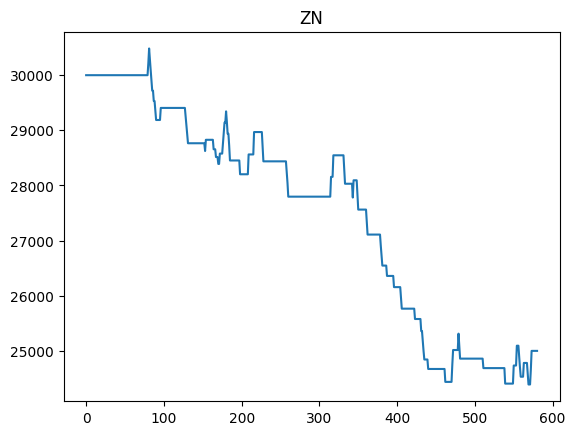

In [111]:
plt.plot(equity_c)
plt.title(ASSET)
plt.show()


In [112]:
trades_c_s, equity_c_s = run_backtest_complete_scalein(df_for_bt, specs[ASSET], initial_capital=specs[ASSET]["initial_margin"]*10)

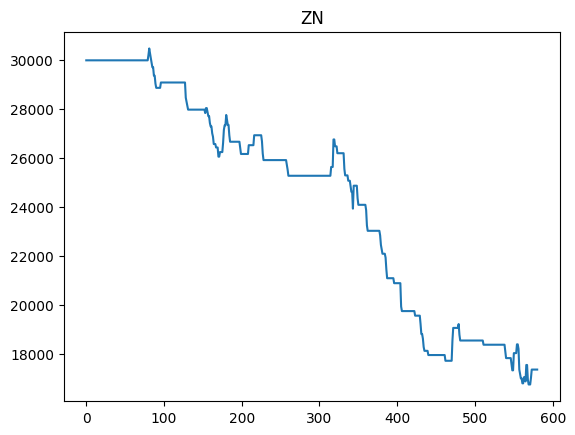

In [113]:
plt.plot(equity_c_s)
plt.title(ASSET)
plt.show()


In [114]:
trades_c_si, equity_c_si = run_backtest_sizing_only(df_for_bt, specs[ASSET], initial_capital=specs[ASSET]["initial_margin"]*10)

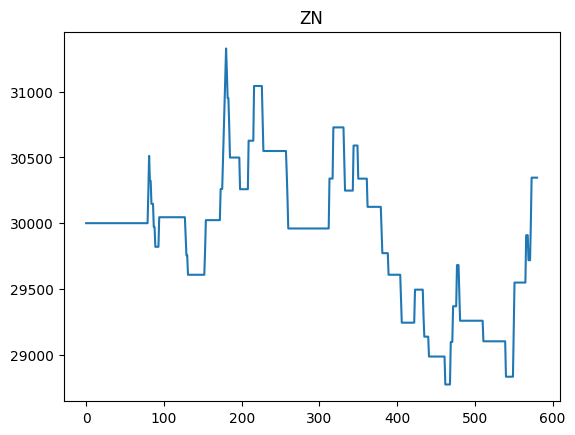

In [115]:
plt.plot(equity_c_si)
plt.title(ASSET)
plt.show()


In [116]:
trades_c_todo, equity_c_todo = run_backtest_scalein_sizing(df_for_bt, specs[ASSET], initial_capital=specs[ASSET]["initial_margin"]*10)

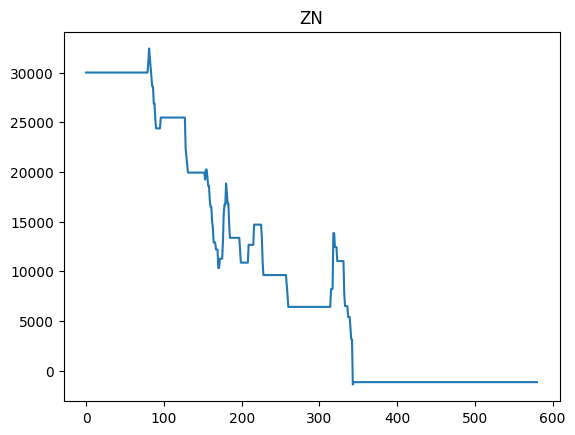

In [117]:
plt.plot(equity_c_todo)
plt.title(ASSET)
plt.show()


In [118]:
# 1. Crear el DataFrame
df = pd.DataFrame({
    "equity_c": equity_c,
    "equity_c_s": equity_c_s,
    "equity_c_si": equity_c_si,
    "equity_c_todo": equity_c_todo
}).astype(float)

# 2. Seleccionar la columna con mayor equity final
best_col = df.iloc[-1].idxmax()

profit = df.iloc[-1].max() - specs[ASSET]["initial_margin"]*10

print("Mejor ganancia:", profit)

equity = df[best_col]

print("Mejor equity:", best_col)

# 3. Calcular MDD
rolling_max = equity.cummax()
drawdown = (rolling_max - equity) / rolling_max
max_dd = drawdown.max()

dd_usd = (rolling_max - equity).max()
eps = 1e-9
ratio = profit / max(dd_usd, eps)
print("Max Drawdown:", dd_usd)

print("Ratio:", ratio)

Mejor ganancia: 345.914376461973
Mejor equity: equity_c_si
Max Drawdown: 2553.0430494416105
Ratio: 0.13549100808841816


In [119]:
# equity = pd.Series(equity_c)
equity = equity.dropna()
returns = equity.pct_change().dropna()
vol_daily = returns.std()
vol_annual = vol_daily * np.sqrt(252)
total_return = equity.iloc[-1] / equity.iloc[0] - 1
months = len(equity) / 21  # aprox 21 días de trading por mes
cagr = (1 + total_return)**(12 / months) - 1
sharpe = cagr / vol_annual



In [120]:
rolling_max = equity.cummax()
drawdown = (rolling_max - equity) / rolling_max
max_dd = drawdown.max()

In [121]:
sharpe

np.float64(0.11951854709911283)

In [122]:
cagr

np.float64(0.0049849421806758)

In [123]:
max_dd

np.float64(0.08149545754470855)

In [124]:
calmar = cagr / max_dd


In [125]:
calmar

np.float64(0.06116834398949232)

In [126]:
dict_trades ={
    "equity_c": trades_c,
    "equity_c_s": trades_c_s,
    "equity_c_si": trades_c_si,
    "equity_c_todo": trades_c_todo
}

In [127]:
import pandas as pd

trades_df = pd.DataFrame(dict_trades[best_col])
trades_df["datetime_exit"] = pd.to_datetime(trades_df["datetime_exit"])
trades_df = trades_df.sort_values("datetime_exit").reset_index(drop=True)


In [128]:
trades_df["week"] = trades_df["datetime_exit"].dt.isocalendar().week
trades_df["year"] = trades_df["datetime_exit"].dt.isocalendar().year
weekly = trades_df.groupby(["year", "week"])["pnl_usd"].sum().reset_index()


In [129]:
trades_df["date"] = trades_df["datetime_exit"].dt.date
daily = trades_df.groupby("date")["pnl_usd"].sum().reset_index()


In [130]:
# weekly_pnl = weekly["pnl_usd"].values
weekly_pnl = daily["pnl_usd"].values

blocks, block_size = build_overlapping_blocks(weekly_pnl, block_size=1)
print("block_size usado:", block_size)
print("n_blocks:", len(blocks))

mc = monte_carlo_blocks(blocks, len(weekly_pnl), n_sims=5000)


block_size usado: 1
n_blocks: 37


In [131]:
mc

array([[-240.6334478 ,  594.32031214, -214.32242124, ..., -212.28732607,
         368.44432852, -357.13614858],
       [ 106.45156507,  715.42609084,  715.42609084, ..., -364.19056302,
         221.47940201, -357.13614858],
       [ 594.32031214, -212.28732607,  594.32031214, ...,  359.87090156,
        -359.45855034, -494.0390795 ],
       ...,
       [-289.73696784,  146.72255028,  715.42609084, ..., -236.13994577,
        -147.40155183,  715.42609084],
       [ 594.32031214, -359.45855034, -236.13994577, ..., -289.73696784,
         594.32031214,  715.42609084],
       [ 146.72255028,  415.04425181,  221.47940201, ..., -212.28732607,
        -212.28732607, -326.21559676]], shape=(5000, 37))

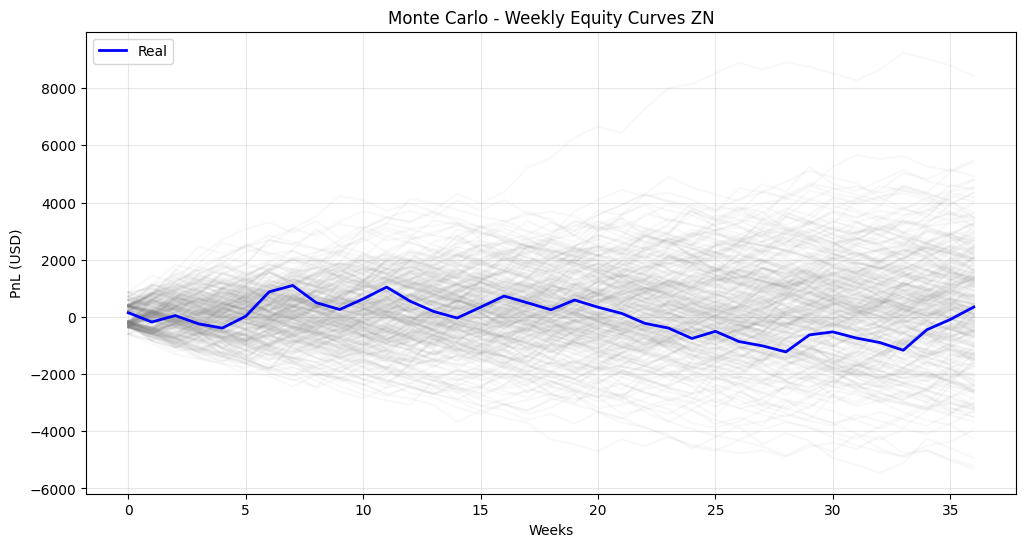

In [132]:

# equity real
real_equity = weekly_pnl.cumsum()

# equity simulada
mc_equity = mc.cumsum(axis=1)

plt.figure(figsize=(12,6))

# muchas curvas simuladas
for i in range(300):   # 300 para no saturar
    plt.plot(mc_equity[i], color="gray", alpha=0.05)

# curva real
plt.plot(real_equity, color="blue", linewidth=2, label="Real")

plt.title(f"Monte Carlo - Weekly Equity Curves {ASSET}")
plt.xlabel("Weeks")
plt.ylabel("PnL (USD)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [133]:
initial_capital = 1_000_000
pnl_cumsum = np.cumsum(mc, axis=1)  # shape (5000, 16)
equity_curves = initial_capital + pnl_cumsum

# Percentiles en cada punto temporal
p5  = np.percentile(equity_curves, 5,  axis=0)
p25 = np.percentile(equity_curves, 25, axis=0)
p50 = np.percentile(equity_curves, 50, axis=0)
p75 = np.percentile(equity_curves, 75, axis=0)
p95 = np.percentile(equity_curves, 95, axis=0)

In [134]:
final_equity = equity_curves[:, -1]  # shape (5000,)

pct_positive = (final_equity > initial_capital).mean() * 100
expected_final = final_equity.mean()
worst_case  = np.percentile(final_equity, 5)   # VaR al 95%
best_case   = np.percentile(final_equity, 95)
median_final = np.median(final_equity)

In [135]:
def max_drawdown(equity_row):
    peak = np.maximum.accumulate(equity_row)
    dd = (equity_row - peak) / peak
    return dd.min()

mdd_per_sim = np.array([max_drawdown(eq) for eq in equity_curves])

print(f"Median MDD : {np.median(mdd_per_sim):.1%}")
print(f"Worst MDD (p95): {np.percentile(mdd_per_sim, 5):.1%}")

Median MDD : -0.2%
Worst MDD (p95): -0.4%


In [136]:
def max_losing_streak(pnl_row):
    streak = max_streak = 0
    for p in pnl_row:
        streak = streak + 1 if p < 0 else 0
        max_streak = max(max_streak, streak)
    return max_streak

streaks = np.array([max_losing_streak(row) for row in mc])
print(f"Racha perdedora mediana: {np.median(streaks):.0f} trades")
print(f"Racha perdedora p95:     {np.percentile(streaks, 5):.0f} trades")

Racha perdedora mediana: 5 trades
Racha perdedora p95:     3 trades


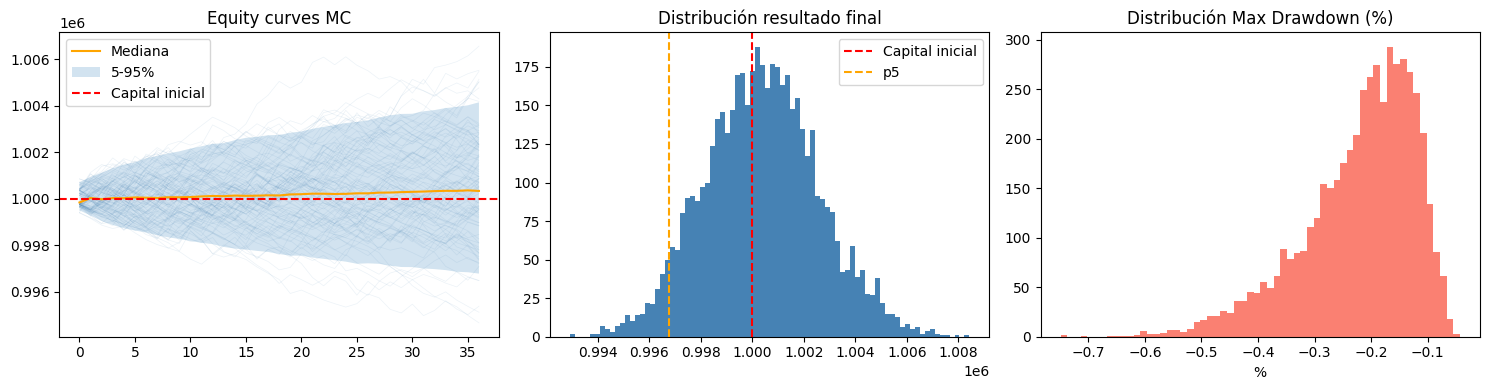

In [137]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1 — Abanico de equity curves
for curve in equity_curves[::50]:  # 1 de cada 50 para no saturar
    axes[0].plot(range(len(curve)), curve, alpha=0.1, color='steelblue', lw=0.5)
axes[0].plot(range(len(curve)), p50, color='orange', label='Mediana')
axes[0].fill_between(range(len(curve)), p5, p95, alpha=0.2, label='5-95%')
axes[0].axhline(initial_capital, color='red', ls='--', label='Capital inicial')
axes[0].set_title('Equity curves MC')
axes[0].legend()

# Panel 2 — Distribución del resultado final
axes[1].hist(final_equity, bins=80, color='steelblue', edgecolor='none')
axes[1].axvline(initial_capital, color='red', ls='--', label='Capital inicial')
axes[1].axvline(worst_case, color='orange', ls='--', label='p5')
axes[1].set_title('Distribución resultado final')
axes[1].legend()

# Panel 3 — Distribución del Max Drawdown
axes[2].hist(mdd_per_sim * 100, bins=60, color='salmon', edgecolor='none')
axes[2].set_title('Distribución Max Drawdown (%)')
axes[2].set_xlabel('%')

plt.tight_layout()